# Magnetic-field initialization, UETC, and spectrum -- illustrative exercise

Side notebook unpacking the paragraph that introduces the magnetic-field two-point function, the initial Batchelor--Kolmogorov spectrum, and the construction rule:

$$\langle \tilde B_i^*(\mathbf k,t_1)\,\tilde B_j(\mathbf k',t_2)\rangle = (2\pi)^6 \delta^3(\mathbf k-\mathbf k')\,P_{ij}(\mathbf k)\,\frac{E_M(k,t_1,t_2)}{4\pi k^2}, \qquad (5)$$

$$P_{ij}(\mathbf k) = \delta_{ij} - \hat k_i\hat k_j,$$

$$E_M(k,t_*) = (1+D)^{1/\alpha} E_M^*\,\frac{(k/k_*)^4}{\bigl[1+D(k/k_*)^{\alpha(4+5/3)}\bigr]^{1/\alpha}},\quad D=12/5,\;\alpha=2, \qquad (6)$$

$$\tilde B_i(\mathbf k,t_*) = P_{ij}(\mathbf k)\,g_j(\mathbf k)\,g_0(\mathbf k),\qquad \langle g_i(\mathbf x)g_j(\mathbf x')\rangle = \delta_{ij}\delta^3(\mathbf x-\mathbf x'),\qquad g_0(\mathbf k)=\sqrt{E_M(k,t_*)/k}. \qquad (7)$$

**Goal.** Make every Fourier transform behind (5)--(7) explicit, then plot $E_M(k)$ directly from Eq. (6) and as recovered from the FT of a $\tilde B$ field constructed via Eq. (7), and verify they overlay. Close with the asymptotic Batchelor--Kolmogorov shape over a wide $k$ range.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import beta as Bfun

# Project plot style (Okabe-Ito palette, Computer Modern via usetex, 3.5x3.5 baseline).
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from gw_turbulence.plot_style import apply_paper_style, FIGSIZES, PALETTE, apply_max_ticks
apply_paper_style()

rng = np.random.default_rng(0)

## 1. Fourier-transform convention

Asymmetric (physicist's) convention -- $(2\pi)^3$ in the inverse:

$$B(\mathbf x) = \int\frac{d^3k}{(2\pi)^3}\,\tilde B(\mathbf k)\,e^{+i\mathbf k\cdot\mathbf x},\qquad \tilde B(\mathbf k) = \int d^3x\,B(\mathbf x)\,e^{-i\mathbf k\cdot\mathbf x}.$$


$$\int d^3x\,e^{i(\mathbf k-\mathbf k')\cdot\mathbf x} = (2\pi)^3 \delta^3(\mathbf k-\mathbf k').$$

Every $(2\pi)^N$ in Eq. (5) traces back to this identity applied once per FT leg.

## 2. $\delta$-correlated vector field $\leftrightarrow$ flat $k$-space spectrum

From $\langle g_i(\mathbf x)g_j(\mathbf x')\rangle = \delta_{ij}\delta^3(\mathbf x-\mathbf x')$, transform both arguments:

$$\langle \tilde g_i^*(\mathbf k)\,\tilde g_j(\mathbf k')\rangle = \delta_{ij}\!\int d^3x\,e^{i(\mathbf k-\mathbf k')\cdot\mathbf x} = (2\pi)^3 \delta_{ij}\delta^3(\mathbf k-\mathbf k').$$

Numerical check:

In [2]:
N, L = 64, 2*np.pi
dx = L/N
g = rng.normal(0.0, 1.0/np.sqrt(dx**3), size=(3, N, N, N))
g_k = np.fft.fftn(g, axes=(1,2,3)) * dx**3
mean_per_mode_per_i = (np.abs(g_k)**2).sum(axis=0).mean() / 3.0
print(f'  <|tg|^2>_(k,i)  numerical  =  {mean_per_mode_per_i:.4f}')
print(f'  (2 pi)^3         analytical =  {(2*np.pi)**3:.4f}')
print(f'  relative error               =  {abs(mean_per_mode_per_i/(2*np.pi)**3 - 1):.2%}')

  <|tg|^2>_(k,i)  numerical  =  248.3041
  (2 pi)^3         analytical =  248.0502
  relative error               =  0.10%


## 3. Transverse projector $P_{ij}(\mathbf k) = \delta_{ij} - \hat k_i\hat k_j$

Three identities make Eq. (7) automatically produce a divergence-free two-polarization field:
- $k_i P_{ij} = 0$  ($\Rightarrow\nabla\cdot B = 0$)
- $P_{ij}P_{jl} = P_{il}$  (idempotent)
- $\mathrm{tr}\,P = 2$

In [3]:
k_vec = np.array([0.7, -0.3, 1.4])
khat  = k_vec / np.linalg.norm(k_vec)
P     = np.eye(3) - np.outer(khat, khat)
print(f'  k . P            =  {np.linalg.norm(k_vec @ P):.2e}   (analytic: 0)')
print(f'  ||P^2 - P||      =  {np.linalg.norm(P @ P - P):.2e}   (analytic: 0)')
print(f'  tr P             =  {np.trace(P):.6f}     (analytic: 2)')

  k . P            =  7.85e-17   (analytic: 0)
  ||P^2 - P||      =  1.16e-16   (analytic: 0)
  tr P             =  2.000000     (analytic: 2)


## 4. From Eq. (7) to Eq. (5): identification of $g_0(k)^2$

Take $\tilde B_i(\mathbf k) = P_{im}(\mathbf k)\tilde g_m(\mathbf k)g_0(\mathbf k)$ and form the two-point:

$$\langle \tilde B_i^*(\mathbf k)\tilde B_j(\mathbf k')\rangle = P_{im}(\mathbf k)P_{jn}(\mathbf k')g_0(\mathbf k)g_0(\mathbf k')\,(2\pi)^3\delta_{mn}\delta^3(\mathbf k-\mathbf k') = (2\pi)^3\delta^3(\mathbf k-\mathbf k')\,P_{ij}(\mathbf k)\,g_0^2(\mathbf k),$$

using $P_{in}P_{jn}=P_{ij}$. Matching to Eq. (5):

$$\boxed{\,g_0^2(\mathbf k) \;=\; (2\pi)^3\,\frac{E_M(k)}{4\pi k^2}\,}$$

The paper's compact "$g_0=\sqrt{E_M/k}$" is the same identification with the convention-dependent constant $(2\pi)^3/(4\pi k)$ absorbed into the $(2\pi)^6$ of Eq. (5).

## 5. Batchelor--Kolmogorov shape (Eq. 6): peak, normalization, $B_{\rm rms}^2$

With $a=4$ (IR), $b=5/3$ (UV), $\alpha=2$:

$$E_M(k) = (1+D)^{1/\alpha} E_M^*\,\frac{x^a}{[1+Dx^{\alpha(a+b)}]^{1/\alpha}},\qquad x=k/k_*.$$

**Peak at $x=1$.** $\partial_x\ln E_M|_{x=1}=0\Rightarrow a(1+D)=D(a+b)\Rightarrow D=a/b=4/(5/3)=12/5$.

**$B_{\rm rms}^2$ closed form** (Beta function via $u=Dx^{\alpha(a+b)}$):

$$\int_0^\infty E_M(k)\,dk = E_M^*\,k_*\,\frac{(1+D)^{1/\alpha}}{\alpha(a+b)}\,D^{-(a+1)/(\alpha(a+b))}\,B(p,q),\quad p=\frac{a+1}{\alpha(a+b)},\quad q=\frac{1}{\alpha}-p.$$

For $(a,b,\alpha)=(4,5/3,2)$: $p=15/34$, $q=1/17$.

In [4]:
a, b, alpha = 4.0, 5.0/3.0, 2.0
D = a/b

def E_M_spec(k, kstar=1.0, EMstar=1.0, D=D, alpha=alpha, a=a, b=b):
    x = k/kstar
    return (1+D)**(1/alpha) * EMstar * x**a / (1 + D * x**(alpha*(a+b)))**(1/alpha)

p = (a+1)/(alpha*(a+b))
q = 1/alpha - p
I_analytic = (1+D)**(1/alpha)/(alpha*(a+b)) * D**(-(a+1)/(alpha*(a+b))) * Bfun(p, q)
I_numeric, _ = quad(E_M_spec, 0.0, np.inf, limit=400)

print(f'  D = a/b              =  {D}')
print(f'  p, q                 =  {p:.4f}, {q:.4f}')
print(f'  I_analytic (B-fn)    =  {I_analytic:.6f}')
print(f'  I_numeric  (quad)    =  {I_numeric:.6f}')
print(f'  relative error        =  {abs(I_analytic/I_numeric - 1):.2e}')
print(f'  -->  B_rms^2 = ({I_analytic:.4f}) E*_M k*')

  D = a/b              =  2.4
  p, q                 =  0.4412, 0.0588
  I_analytic (B-fn)    =  2.063891
  I_numeric  (quad)    =  2.063891
  relative error        =  5.00e-15
  -->  B_rms^2 = (2.0639) E*_M k*


## 6. Plot $E_M(k)$: direct (Eq. 6) vs. recovered from the FT construction (Eq. 7)

Build $\tilde B_i(\mathbf k)$ on a discrete grid via Eq. (7) and recover its spectrum from the field itself, then compare against $E_M(k)$ from Eq. (6).

**Discrete bookkeeping.** On a periodic box of side $L$ with $N^3$ grid, $d^3k=(2\pi/L)^3$, so $\delta^3(0)\to V_{\rm box}/(2\pi)^3$. Eq. (5) per mode becomes

$$\bigl\langle |\tilde B(\mathbf k)|^2\bigr\rangle_{\rm mode} = 2\,V_{\rm box}\,(2\pi)^3\,\frac{E_M(k)}{4\pi k^2},$$

so the unbiased estimator from a shell of modes is

$$\widehat{E_M}(k) = \frac{4\pi k^2}{2\,V_{\rm box}\,(2\pi)^3}\,\bigl\langle|\tilde B|^2(k)\bigr\rangle_{\rm shell}.$$

**Grid choice.** $N^3$ modes span $k\in[2\pi/L,\;\pi N/L]$. With $k_*$ fixed, a smaller $L$ pushes the Nyquist further into the UV (revealing the $k^{-5/3}$ tail); a larger $L$ resolves the deep IR. The defaults below ($N=256$, $L=2\pi$) give a generous UV reach around $k_*=8$.

**Is there a nicer way?** Three options reduce shell-by-shell noise without changing the construction:
1. *Average over realizations* (canonical): error scales as $1/\sqrt{n_{\rm real}}$. Set `n_real` below.
2. *Wider radial bins* in the IR (where few modes live).
3. *Sample with Hermitian symmetry* (`rfftn`-style): half the memory, same statistics.

We expose `n_real` as the cleanest knob; bumping it from 1 to 4 visibly tightens the deep IR.

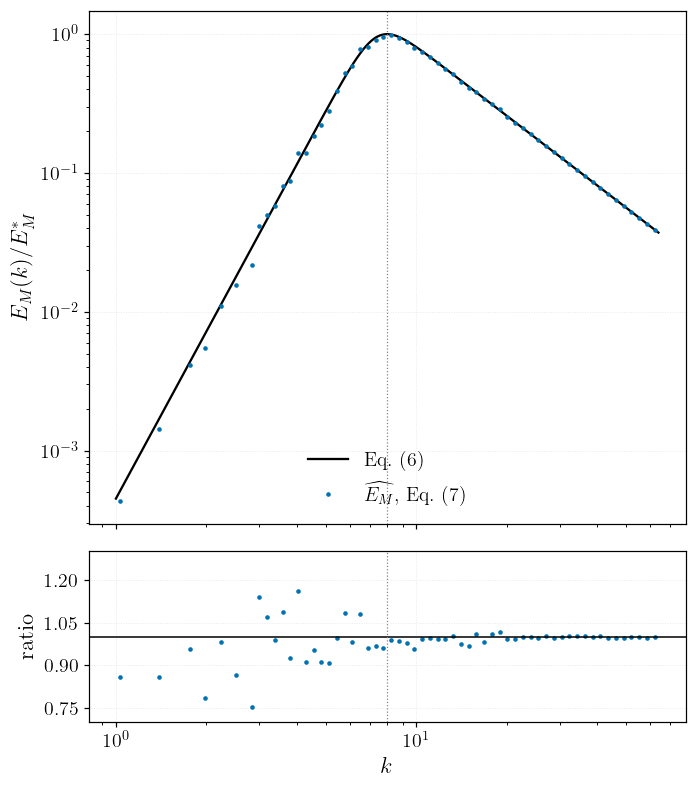

  median ratio (counts > 30) = 0.9960
  mean   ratio                = 0.9921


In [8]:
# --- grid & sampling parameters -----------------------------------------
N      = 256                     # grid points per side
L      = 2*np.pi                 # smaller L pushes Nyquist UV-ward
kstar  = 8.0                     # peak wavenumber in our units
n_real = 2                       # realizations to average (noise ~ 1/sqrt(n_real))
V_box  = L**3

kx = np.fft.fftfreq(N, d=L/N) * 2*np.pi
KX, KY, KZ = np.meshgrid(kx, kx, kx, indexing='ij')
Kmag      = np.sqrt(KX**2 + KY**2 + KZ**2)
Kmag_safe = np.where(Kmag == 0, 1.0, Kmag)

khat_x = KX / Kmag_safe
khat_y = KY / Kmag_safe
khat_z = KZ / Kmag_safe
EMk = E_M_spec(Kmag_safe, kstar=kstar)
g0  = np.sqrt((2*np.pi)**3 * EMk / (4*np.pi * Kmag_safe**2))
g0[Kmag == 0] = 0.0

# Accumulate |tB|^2 over realizations in place (one realization at a time).
B2 = np.zeros_like(Kmag)
for _ in range(n_real):
    sigma = np.sqrt(V_box/2)
    g_x = (rng.normal(size=(N,N,N)) + 1j*rng.normal(size=(N,N,N))) * sigma
    g_y = (rng.normal(size=(N,N,N)) + 1j*rng.normal(size=(N,N,N))) * sigma
    g_z = (rng.normal(size=(N,N,N)) + 1j*rng.normal(size=(N,N,N))) * sigma
    g_dot = g_x*khat_x + g_y*khat_y + g_z*khat_z
    B2 += (np.abs((g_x - g_dot*khat_x) * g0)**2
           + np.abs((g_y - g_dot*khat_y) * g0)**2
           + np.abs((g_z - g_dot*khat_z) * g0)**2)
    del g_x, g_y, g_z, g_dot
B2 /= n_real
B2[Kmag == 0] = 0.0

# Radial shell binning.
nbins = 70
k_edges   = np.logspace(np.log10(2*np.pi/L), np.log10(0.5*np.max(np.abs(kx))), nbins+1)
k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])
counts, _ = np.histogram(Kmag.ravel(), bins=k_edges)
sums,   _ = np.histogram(Kmag.ravel(), bins=k_edges, weights=B2.ravel())
valid = counts > 4
shell_mean = np.zeros_like(k_centers)
shell_mean[valid] = sums[valid] / counts[valid]
E_recovered = 4*np.pi * k_centers**2 / (2 * V_box * (2*np.pi)**3) * shell_mean

k_dense  = np.logspace(np.log10(k_edges[0]), np.log10(k_edges[-1]), 600)
E_direct = E_M_spec(k_dense, kstar=kstar)

# --- plot (project style: Okabe-Ito, 3.5-wide, ratio strip) -----------
fig, (ax, axr) = plt.subplots(2, 1, figsize=(2*3.5, 2*4.2),
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08),
                              sharex=True)
ax.loglog(k_dense, E_direct, '-', color=PALETTE[0], lw=1.5, label=r'Eq.~(6)')
ax.loglog(k_centers[valid], E_recovered[valid], 'o', ms=3.0,
          color=PALETTE[5], mec='none', label=r'$\widehat{E_M}$, Eq.~(7)')
ax.axvline(kstar, color='gray', ls=':', lw=0.8)
ax.set_ylabel(r'$E_M(k)/E_M^\ast$')
ax.legend(loc='lower center', frameon=False)
apply_max_ticks(ax)

ratio = np.full_like(k_centers, np.nan)
Ek = E_M_spec(k_centers, kstar=kstar)
ok = valid & (Ek > 0)
ratio[ok] = E_recovered[ok] / Ek[ok]
axr.semilogx(k_centers, ratio, 'o', ms=3.0, color=PALETTE[5], mec='none')
axr.axhline(1.0, color=PALETTE[0], lw=1.0)
axr.axvline(kstar, color='gray', ls=':', lw=0.8)
axr.set_ylim(0.7, 1.3)
axr.set_xlabel(r'$k$')
axr.set_ylabel(r'ratio')
apply_max_ticks(axr)
plt.show()

well = valid & (counts > 30)
good = E_recovered[well] / E_M_spec(k_centers[well], kstar=kstar)
print(f'  median ratio (counts > 30) = {np.median(good):.4f}')
print(f'  mean   ratio                = {np.mean(good):.4f}')

## 7. Real-space correlator (sanity check)

$$\xi_{ii}(r) = \frac{1}{\pi^2}\int_0^\infty E_M(k)\frac{\sin kr}{kr}\,dk.$$

$\xi_{ii}(0) = I_{\rm analytic}/\pi^2$; at large $r$ the Batchelor $k^4$ IR forces a sign-changing tail.

In [6]:
def xi_ii(r, kstar=1.0, k_max=200.0):
    if r == 0.0:
        v, _ = quad(lambda k: E_M_spec(k, kstar=kstar), 0.0, np.inf, limit=400)
        return v / np.pi**2
    f = lambda k: E_M_spec(k, kstar=kstar) * np.sin(k*r) / (k*r)
    v, _ = quad(f, 0.0, k_max, limit=2000, epsabs=1e-10, epsrel=1e-9)
    return v / np.pi**2

print(f'  xi_ii(0)             = {xi_ii(0.0):.6f}')
print(f'  I_analytic / pi^2    = {I_analytic/np.pi**2:.6f}   (must match)')
print()
print(f"       r        xi_ii(r)")
for r in [0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]:
    print(f'    {r:6.2f}    {xi_ii(r):+.4e}')

  xi_ii(0)             = 0.209116
  I_analytic / pi^2    = 0.209116   (must match)

       r        xi_ii(r)
      0.00    +2.0912e-01
      0.50    +1.2053e-01
      1.00    +7.5591e-02
      2.00    +2.3546e-02
      4.00    -5.3629e-03
      8.00    +7.8521e-04
     16.00    +3.9335e-05


## 8. Batchelor--Kolmogorov asymptotic shape

Pure analytical view of Eq. (6) over many decades, with the two limiting power laws called out:

$$E_M(k)/E_M^\ast \;\sim\; (1+D)^{1/\alpha}\,(k/k_\ast)^{4} \quad (k\ll k_\ast,\ \text{Batchelor}),$$

$$E_M(k)/E_M^\ast \;\sim\; (1+D)^{1/\alpha}\,D^{-1/\alpha}\,(k/k_\ast)^{-5/3} \quad (k\gg k_\ast,\ \text{Kolmogorov}).$$

Both prefactors come from collapsing $[\,1+Dx^{\alpha(a+b)}\,]^{1/\alpha}$ to its dominant term in each limit.

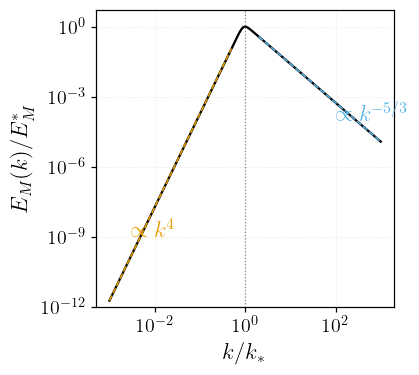

  IR check  E_M / [(1+D)^(1/a) x^4]            at x=1e-3  =  1.000000
  UV check  E_M / [(1+D)^(1/a) D^(-1/a) x^(-5/3)]  at x=1e3 =  1.000000
  Both should approach 1.


In [7]:
x = np.logspace(-3, 3, 1200)
E = E_M_spec(x, kstar=1.0)

ir_pref = (1 + D)**(1/alpha)
uv_pref = (1 + D)**(1/alpha) * D**(-1/alpha)

fig, ax = plt.subplots(figsize=FIGSIZES['small'])
ax.loglog(x, E, '-', color=PALETTE[0], lw=1.5)
x_ir = np.logspace(-3, -0.3, 100)
ax.loglog(x_ir, ir_pref * x_ir**4, '--', color=PALETTE[1], lw=1.0)
x_uv = np.logspace(0.3, 3, 100)
ax.loglog(x_uv, uv_pref * x_uv**(-5/3), '--', color=PALETTE[2], lw=1.0)
ax.axvline(1.0, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'$k/k_\ast$')
ax.set_ylabel(r'$E_M(k)/E_M^\ast$')
ax.set_ylim(1e-12, 5.0)
ax.text(3e-3, 1e-9,  r'$\propto k^{4}$',     color=PALETTE[1])
ax.text(1e2,  1e-4,  r'$\propto k^{-5/3}$', color=PALETTE[2])
apply_max_ticks(ax)
plt.show()

# Asymptotic-prefactor check.
x_far_ir, x_far_uv = 1e-3, 1e3
ratio_ir = E_M_spec(x_far_ir, kstar=1.0) / (ir_pref * x_far_ir**4)
ratio_uv = E_M_spec(x_far_uv, kstar=1.0) / (uv_pref * x_far_uv**(-5/3))
print(f'  IR check  E_M / [(1+D)^(1/a) x^4]            at x=1e-3  =  {ratio_ir:.6f}')
print(f'  UV check  E_M / [(1+D)^(1/a) D^(-1/a) x^(-5/3)]  at x=1e3 =  {ratio_uv:.6f}')
print(f'  Both should approach 1.')